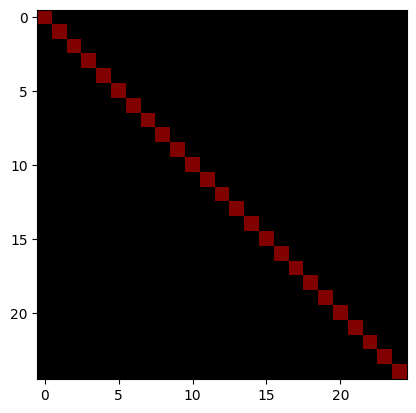

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

w = 25
h = 25
img1 = np.zeros((w, h, 3), dtype=np.uint8)
for i in range(w):
    for j in range(h):
        if j == i:
            img1[i][j][0] = 128

plt.imshow(img1)
plt.show()

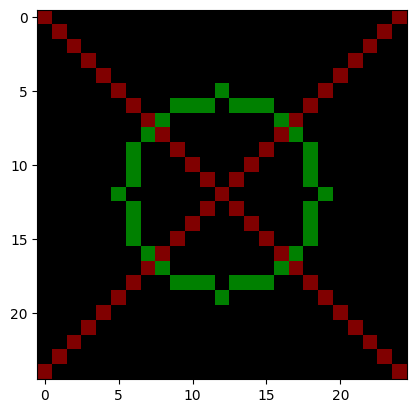

In [2]:
cv2.line(img1, (0, h-1), (w-1, 0), (128, 0, 0))
cv2.circle(img1, (w // 2, h // 2), 7, (0, 128, 0))
plt.imshow(img1)
plt.show()

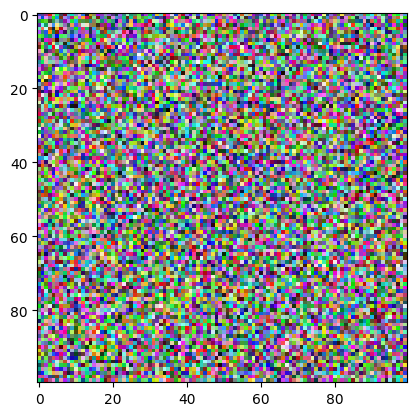

In [3]:
img2 = np.random.randint(0, 256, (100, 100, 3), dtype=np.uint8)
plt.imshow(img2)
plt.show()

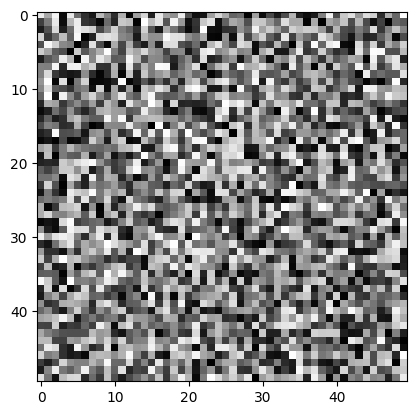

In [4]:
img3 = np.random.randint(0, 256, (50, 50), dtype=np.uint8)
plt.imshow(img3, cmap="gray")
plt.show()

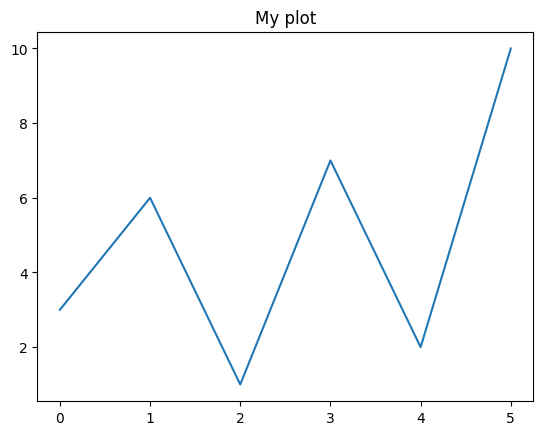

In [5]:
values = np.array([3,6,1,7,2,10])
plt.plot(values)
plt.title("My plot")
plt.show()

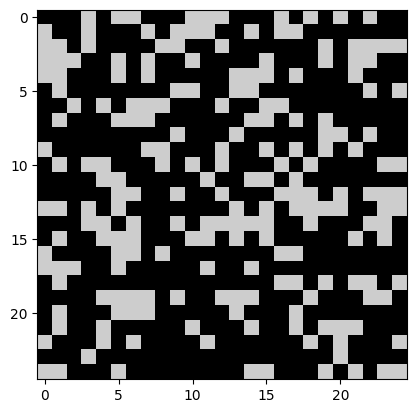

In [6]:
import random
background = np.full((w, h), 205, dtype=np.uint8)
for i in range(w):
    for j in range(h):
        background[i][j] = 0 if random.randint(0, 2) else 205

plt.imshow(background, cmap="gray", vmin = 0, vmax=255)

from IPython.display import clear_output, display
import time

def numberOfAliveNeighbours(x: int, y: int):
    summ = 0
    for ii in range(x-1 if x>0 else x, x+2 if x < (w-1) else x+1):
        for jj in range(y-1 if y>0 else y, y+2 if y < (h-1) else y+1):
            if background[ii][jj] == 0:
                summ = summ + 1
    return summ if background[x][y] != 0 else summ-1
    
def calculateCell(x: int, y: int):
    res = numberOfAliveNeighbours(x, y)
    return 0 if (res == 2 and background[x][y] == 0) or res == 3 else 205 
    

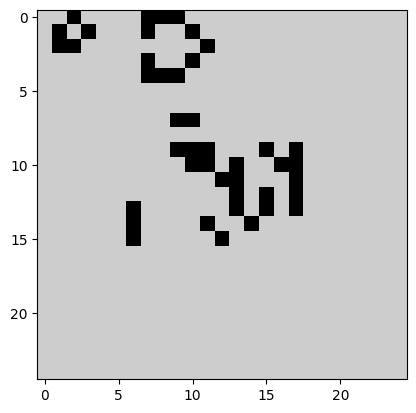

In [7]:
import copy
def calculate():
    new_bg = copy.copy(background)
    for i in range(w):
        for j in range(h):
            new_bg[i][j] = calculateCell(i, j)
    return new_bg

for t in range (50): #because there are situations when the plot is changing and should be stopped somehow
    nbg = calculate()
    if (background == nbg).all():
        break
    background = nbg
    del nbg
    plt.imshow(background, cmap="gray", vmin = 0, vmax=255)
    display(plt.gcf())
    clear_output(wait=True)
    time.sleep(1)